<a href="https://colab.research.google.com/github/ssj27072002/Deep-Learning-IT549/blob/main/202511048_ShubhamJoshi_Imitating_FakeSpot_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch spacy wordcloud pandas scikit-learn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import torch
import spacy
import re
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
df = pd.read_csv('fake_reviews_dataset.csv')
df['text_'] = df['text_'].astype(str)

def fast_tokenize(texts):
    tokens_list = []
    for doc in nlp.pipe(texts, batch_size=1000):
        tokens_list.append([t.lemma_ for t in doc if not t.is_stop and t.is_alpha])
    return tokens_list

df['tokens'] = fast_tokenize(df['text_'].tolist())
all_tokens = [t for sublist in df['tokens'] for t in sublist]
vocab = {word: i+1 for i, (word, _) in enumerate(Counter(all_tokens).most_common(10000))}

def encode_pad(tokens, max_len=100):
    encoded = [vocab.get(t, 0) for t in tokens[:max_len]]
    return encoded + [0] * (max_len - len(encoded))

X = torch.tensor([encode_pad(t) for t in df['tokens']])
le_cat = LabelEncoder()
y_cat = torch.tensor(le_cat.fit_transform(df['category']), dtype=torch.long)
le_label = LabelEncoder()
y_label = torch.tensor(le_label.fit_transform(df['label']), dtype=torch.long)

class ReviewDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

train_idx, test_idx = train_test_split(range(len(X)), test_size=0.2, random_state=42, stratify=df['category'])

In [13]:
import torch.nn as nn

class MulticlassClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.network = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        embedded = self.embedding(x).mean(dim=1)
        return self.network(embedded)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader = DataLoader(ReviewDataset(X[train_idx], y_cat[train_idx]), batch_size=64, shuffle=True)
test_loader = DataLoader(ReviewDataset(X[test_idx], y_cat[test_idx]), batch_size=64)

cat_model = MulticlassClassifier(len(vocab), 100, len(le_cat.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cat_model.parameters(), lr=0.001)

for epoch in range(5):
    cat_model.train()
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(cat_model(texts), labels)
        loss.backward()
        optimizer.step()

cat_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        outputs = cat_model(texts.to(device))
        y_true.extend(labels.tolist())
        y_pred.extend(torch.argmax(outputs, dim=1).cpu().tolist())

print(classification_report(y_true, y_pred, target_names=le_cat.classes_))

                              precision    recall  f1-score   support

                     Books_5       0.70      0.71      0.70       874
Clothing_Shoes_and_Jewelry_5       0.73      0.79      0.76       770
               Electronics_5       0.78      0.74      0.76       798
          Home_and_Kitchen_5       0.61      0.60      0.61       811
              Kindle_Store_5       0.75      0.72      0.74       946
             Movies_and_TV_5       0.89      0.87      0.88       717
              Pet_Supplies_5       0.86      0.83      0.85       851
       Sports_and_Outdoors_5       0.51      0.54      0.52       789
Tools_and_Home_Improvement_5       0.65      0.63      0.64       772
            Toys_and_Games_5       0.76      0.80      0.78       759

                    accuracy                           0.72      8087
                   macro avg       0.72      0.72      0.72      8087
                weighted avg       0.72      0.72      0.72      8087



In [14]:
class BinaryClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.network = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        embedded = self.embedding(x).mean(dim=1)
        return self.network(embedded)

train_loader_b = DataLoader(ReviewDataset(X[train_idx], y_label[train_idx]), batch_size=64, shuffle=True)
test_loader_b = DataLoader(ReviewDataset(X[test_idx], y_label[test_idx]), batch_size=64)

bin_model = BinaryClassifier(len(vocab), 100).to(device)
optimizer_b = torch.optim.Adam(bin_model.parameters(), lr=0.001)

for epoch in range(5):
    bin_model.train()
    for texts, labels in train_loader_b:
        texts, labels = texts.to(device), labels.to(device)
        optimizer_b.zero_grad()
        loss = criterion(bin_model(texts), labels)
        loss.backward()
        optimizer_b.step()

bin_model.eval()
y_true_b, y_pred_b = [], []
with torch.no_grad():
    for texts, labels in test_loader_b:
        outputs = bin_model(texts.to(device))
        y_true_b.extend(labels.tolist())
        y_pred_b.extend(torch.argmax(outputs, dim=1).cpu().tolist())

print(classification_report(y_true_b, y_pred_b, target_names=le_label.classes_))

              precision    recall  f1-score   support

          CG       0.86      0.85      0.85      4102
          OR       0.84      0.85      0.85      3985

    accuracy                           0.85      8087
   macro avg       0.85      0.85      0.85      8087
weighted avg       0.85      0.85      0.85      8087



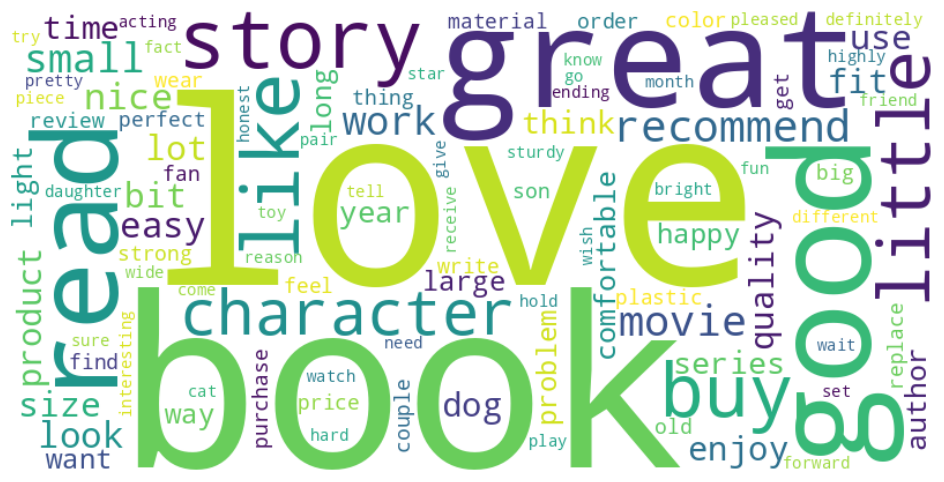

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

fake_tokens = df[df['label'] == 'CG']['tokens'].tolist()
word_counts = Counter([word for sublist in fake_tokens for word in sublist])
wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate_from_frequencies(word_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()